In [1]:
# 加载数据 查看完整schema
import polars as pl
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pl.read_parquet("../data/processed/core_stop_events.parquet")

print(df.shape)
print(df.columns)
print(df.schema)
df.head(10)

(994117, 18)
['fzg_id', 'drop_row_idx', 'arrival_time', 'departure_time', 'linie', 'fahrt_id', 'ort_nr_start', 'stop_index', 'stop_status', 'scheduled_arrival_time', 'delay_calculated_sec', 'delay_recorded_sec', 'dwell_time', 'travel_time', 'besetztgrad', 'is_peak_hour', 'is_workday', 'has_traffic_signal']
Schema([('fzg_id', Int64), ('drop_row_idx', Int64), ('arrival_time', Datetime(time_unit='us', time_zone='UTC')), ('departure_time', Datetime(time_unit='us', time_zone='UTC')), ('linie', Int64), ('fahrt_id', Int64), ('ort_nr_start', Int64), ('stop_index', Int64), ('stop_status', String), ('scheduled_arrival_time', Datetime(time_unit='us', time_zone='UTC')), ('delay_calculated_sec', Float64), ('delay_recorded_sec', Int64), ('dwell_time', Float64), ('travel_time', Float64), ('besetztgrad', Int64), ('is_peak_hour', Int8), ('is_workday', Int8), ('has_traffic_signal', Int8)])


fzg_id,drop_row_idx,arrival_time,departure_time,linie,fahrt_id,ort_nr_start,stop_index,stop_status,scheduled_arrival_time,delay_calculated_sec,delay_recorded_sec,dwell_time,travel_time,besetztgrad,is_peak_hour,is_workday,has_traffic_signal
i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,i64,str,"datetime[μs, UTC]",f64,i64,f64,f64,i64,i8,i8,i8
151,106,2025-07-29 02:23:41.605618 UTC,2025-07-29 02:23:54.604010 UTC,4,5924129,184104,0,"""normal""",2025-07-29 02:22:00 UTC,101.605618,-10,12.998392,null,1,0,1,null
151,116,2025-07-29 02:25:44.604703 UTC,2025-07-29 02:25:44.604703 UTC,4,5924129,182302,1,"""no_door""",2025-07-29 02:24:00 UTC,104.604703,-20,-1.0,110.000693,0,0,1,null
151,124,2025-07-29 02:26:37.622760 UTC,2025-07-29 02:26:37.622760 UTC,4,5924129,182402,2,"""no_door""",2025-07-29 02:26:00 UTC,37.62276,-20,-1.0,53.018057,0,0,1,null
151,131,2025-07-29 02:27:48.626588 UTC,2025-07-29 02:27:59.624717 UTC,4,5924129,181801,3,"""normal""",2025-07-29 02:27:00 UTC,48.626588,0,10.998129,71.003828,0,0,1,null
151,138,2025-07-29 02:29:08.629491 UTC,2025-07-29 02:29:08.629491 UTC,4,5924129,181901,4,"""no_door""",2025-07-29 02:28:00 UTC,68.629491,0,-1.0,69.004774,0,0,1,null
151,142,2025-07-29 02:30:47.632904 UTC,2025-07-29 02:30:47.632904 UTC,4,5924129,182001,5,"""normal""",2025-07-29 02:29:00 UTC,107.632904,0,0.0,99.003413,0,0,1,null
151,148,2025-07-29 02:30:47.632904 UTC,2025-07-29 02:31:06.628897 UTC,4,5924129,182101,6,"""normal""",2025-07-29 02:30:00 UTC,47.632904,0,18.995993,0.0,0,0,1,null
151,155,2025-07-29 02:31:43.638665 UTC,2025-07-29 02:32:05.650389 UTC,4,5924129,182201,7,"""normal""",2025-07-29 02:31:00 UTC,43.638665,0,22.011724,37.009768,0,0,1,null
151,160,2025-07-29 02:32:55.640975 UTC,2025-07-29 02:32:55.640975 UTC,4,5924129,182601,8,"""no_door""",2025-07-29 02:32:00 UTC,55.640975,-10,-1.0,49.990586,0,0,1,null


In [2]:
# 看线路分布 选择一条高频线路 看是否有trip/序号字段
# 各线路样本量
print(df["linie"].value_counts().sort("count", descending=True))

# 看一个具体车辆+线路的若干行,观察时间顺序、是否能看出trip边界
# (fzg_id是车辆/任务标识,先按它+arrival_time排序看看相邻行的关系)
sample_line = df["linie"].value_counts().sort("count", descending=True)[0, "linie"]
df.filter(pl.col("linie") == sample_line).sort(["fzg_id", "arrival_time"]).head(20)

shape: (43, 2)
┌───────┬───────┐
│ linie ┆ count │
│ ---   ┆ ---   │
│ i64   ┆ u32   │
╞═══════╪═══════╡
│ 4     ┆ 69213 │
│ 61    ┆ 60891 │
│ 63    ┆ 56816 │
│ 7     ┆ 54362 │
│ 68    ┆ 47575 │
│ …     ┆ …     │
│ 79    ┆ 3154  │
│ 73    ┆ 2555  │
│ 74    ┆ 2080  │
│ 59    ┆ 11    │
│ 60    ┆ 2     │
└───────┴───────┘


fzg_id,drop_row_idx,arrival_time,departure_time,linie,fahrt_id,ort_nr_start,stop_index,stop_status,scheduled_arrival_time,delay_calculated_sec,delay_recorded_sec,dwell_time,travel_time,besetztgrad,is_peak_hour,is_workday,has_traffic_signal
i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,i64,str,"datetime[μs, UTC]",f64,i64,f64,f64,i64,i8,i8,i8
151,106,2025-07-29 02:23:54.604010 UTC,2025-07-29 02:23:54.604010 UTC,4,5924129,184104,0,"""normal""",2025-07-29 02:22:00 UTC,114.60401,-10,0.0,null,1,0,1,null
151,116,2025-07-29 02:25:44.604703 UTC,2025-07-29 02:25:44.604703 UTC,4,5924129,182302,1,"""no_door""",2025-07-29 02:24:00 UTC,104.604703,-20,0.0,110.000693,0,0,1,null
151,124,2025-07-29 02:26:37.622760 UTC,2025-07-29 02:26:37.622760 UTC,4,5924129,182402,2,"""no_door""",2025-07-29 02:26:00 UTC,37.62276,-20,0.0,53.018057,0,0,1,null
151,131,2025-07-29 02:27:59.624717 UTC,2025-07-29 02:27:59.624717 UTC,4,5924129,181801,3,"""normal""",2025-07-29 02:27:00 UTC,59.624717,0,0.0,82.001957,0,0,1,null
151,138,2025-07-29 02:29:08.629491 UTC,2025-07-29 02:29:08.629491 UTC,4,5924129,181901,4,"""no_door""",2025-07-29 02:28:00 UTC,68.629491,0,0.0,69.004774,0,0,1,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
151,240,2025-07-29 02:46:12.718806 UTC,2025-07-29 02:46:12.718806 UTC,4,5924129,174502,15,"""normal""",2025-07-29 02:42:00 UTC,252.718806,180,0.0,206.027469,0,0,1,null
151,247,2025-07-29 02:47:09.729672 UTC,2025-07-29 02:47:09.729672 UTC,4,5924129,175102,16,"""no_door""",2025-07-29 02:43:00 UTC,249.729672,120,0.0,57.010866,0,0,1,null
151,252,2025-07-29 02:47:54.726876 UTC,2025-07-29 02:47:54.726876 UTC,4,5924129,175302,17,"""no_door""",2025-07-29 02:45:00 UTC,174.726876,100,0.0,44.997204,0,0,1,null


In [3]:
# 看一个具体fahrt_id的站点序列,确认travel_time/stop_index的语义
sample_fahrt = (
    df.filter(pl.col("linie") == 4)
    .sort("fahrt_id")
    .select("fahrt_id")
    .row(0)[0]
)

trip_df = df.filter(pl.col("fahrt_id") == sample_fahrt).sort("stop_index")
print(trip_df.select(
    ["stop_index", "ort_nr_start", "arrival_time", "departure_time",
     "dwell_time", "travel_time", "delay_calculated_sec", "stop_status"]
))

# dwell_time分布(整体 vs linie 4),重点看0值占比和分位数
print("=== dwell_time overall ===")
print(df["dwell_time"].describe())
print("zero ratio:", (df["dwell_time"] == 0).mean())

print("=== dwell_time linie 4 ===")
print(df.filter(pl.col("linie") == 4)["dwell_time"].describe())
print("zero ratio:", (df.filter(pl.col("linie") == 4)["dwell_time"] == 0).mean())

# 整体缺失值情况
print(df.null_count())

shape: (25, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ stop_index ┆ ort_nr_sta ┆ arrival_ti ┆ departure ┆ dwell_tim ┆ travel_ti ┆ delay_cal ┆ stop_stat │
│ ---        ┆ rt         ┆ me         ┆ _time     ┆ e         ┆ me        ┆ culated_s ┆ us        │
│ i64        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ec        ┆ ---       │
│            ┆ i64        ┆ datetime[μ ┆ datetime[ ┆ f64       ┆ f64       ┆ ---       ┆ str       │
│            ┆            ┆ s, UTC]    ┆ μs, UTC]  ┆           ┆           ┆ f64       ┆           │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0          ┆ 184104     ┆ 2025-08-03 ┆ 2025-08-0 ┆ 0.0       ┆ 41090.909 ┆ 121.63003 ┆ no_door   │
│            ┆            ┆ 07:28:01.6 ┆ 3 07:28:0 ┆           ┆ 12        ┆ 9         ┆           │
│            ┆            ┆ 30039 UTC  ┆ 1.630039  ┆           ┆           ┆

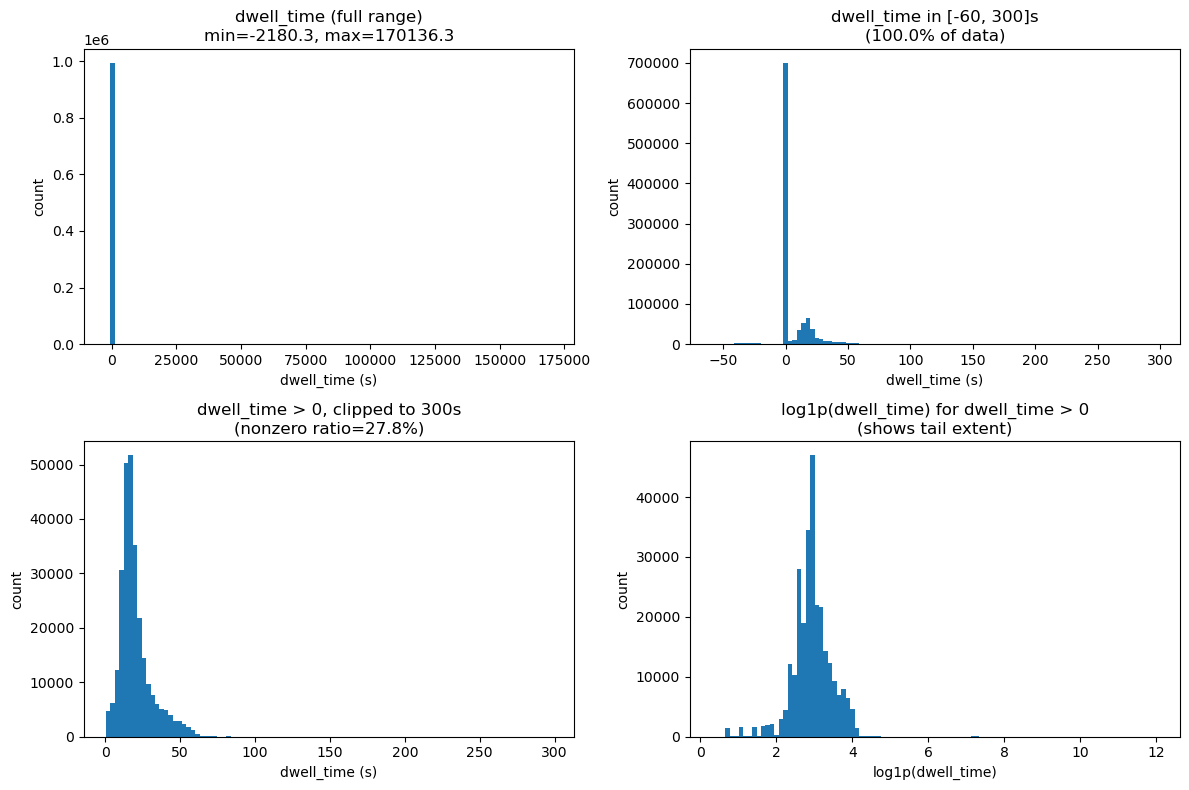

dwell_time > 60s: 0.0879%  (n=874)
dwell_time > 120s: 0.0190%  (n=189)
dwell_time > 300s: 0.0148%  (n=147)
dwell_time > 600s: 0.0107%  (n=106)
dwell_time > 3600s: 0.0024%  (n=24)
dwell_time < 0: 1.9712%  (n=19596)


In [ ]:
import matplotlib.pyplot as plt

dt = df["dwell_time"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. 全量分布(原始尺度) - 极端值会让大部分柱子看不清,但能看出outlier的存在
axes[0, 0].hist(dt, bins=100)
axes[0, 0].set_title(f"dwell_time (full range)\nmin={dt.min():.1f}, max={dt.max():.1f}")
axes[0, 0].set_xlabel("dwell_time (s)")
axes[0, 0].set_ylabel("count")

# 2. clip到[-60, 300]秒后的分布 - 主体形态
mask_main = (dt >= -60) & (dt <= 300)
axes[0, 1].hist(dt[mask_main], bins=100)
axes[0, 1].set_title(f"dwell_time in [-60, 300]s\n({mask_main.mean()*100:.1f}% of data)")
axes[0, 1].set_xlabel("dwell_time (s)")
axes[0, 1].set_ylabel("count")

# 3. 排除0值后的非零分布 - 看真实停站时长的形态
nonzero = dt[dt > 0]
mask_nz = nonzero <= 300
axes[1, 0].hist(nonzero[mask_nz], bins=100)
axes[1, 0].set_title(f"dwell_time > 0, clipped to 300s\n(nonzero ratio={len(nonzero)/len(dt)*100:.1f}%)")
axes[1, 0].set_xlabel("dwell_time (s)")
axes[1, 0].set_ylabel("count")

# 4. log scale查看尾部(只看正值, log1p变换)
pos = dt[dt > 0]
axes[1, 1].hist(np.log1p(pos), bins=100)
axes[1, 1].set_title("log1p(dwell_time) for dwell_time > 0\n(shows tail extent)")
axes[1, 1].set_xlabel("log1p(dwell_time)")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

# 极端值占比的量化参考
for thresh in [60, 120, 300, 600, 3600]:
    print(f"dwell_time > {thresh}s: {(dt > thresh).mean()*100:.4f}%  (n={int((dt > thresh).sum())})")
print(f"dwell_time < 0: {(dt < 0).mean()*100:.4f}%  (n={int((dt < 0).sum())})")